# Live GB forecast

Two display modes from one live weather path:

- **Short** — hourly for the next 24 hours (hour + day models)
- **Medium** — hourly for the next 7 days (week model after hour 24; scored every 30 minutes)

Insights INDO is joined onto elapsed bins.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from energy_forecast.forecast import run_forecast, validation_metrics

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
forecasts = run_forecast(mode="both")
short = forecasts["short"]
medium = forecasts["medium"]
print("short", len(short), "hourly rows")
print("medium", len(medium), "hourly rows")
display(short.head())
display(medium.head())

short 25 hourly rows
medium 28 6-hour rows


,timestamp,lead_hours,p10,p50,p90,actual_mw,temperature_2m,temp_mean_fwd_12h,temp_mean_fwd_24h,temp_delta_24h,...,abs_error,ape,covered,hour,month,year,season,weekday,period_band,lead_band
0,2026-09-25 17:00:00+01:00,0.0,24342.823481,24982.325715,25160.444762,NaN,16.85000,13.783333,14.648177,-1.56250,...,NaN,NaN,False,17,9,2026,autumn,weekday,evening_peak,0-24h
1,2026-09-25 18:00:00+01:00,0.5,24110.358994,24813.671997,25051.473959,NaN,16.26875,13.514323,14.697266,-1.69375,...,NaN,NaN,False,18,9,2026,autumn,weekday,evening_peak,0-24h
2,2026-09-25 19:00:00+01:00,1.5,28558.439254,30421.768747,31564.508460,NaN,15.43750,13.197135,14.770052,-1.58125,...,NaN,NaN,False,19,9,2026,autumn,weekday,evening_peak,0-24h
3,2026-09-25 20:00:00+01:00,2.5,26906.017763,28704.674772,29759.714369,NaN,14.91250,12.945312,14.839453,-1.50000,...,NaN,NaN,False,20,9,2026,autumn,weekday,late_evening,0-24h
4,2026-09-25 21:00:00+01:00,3.5,24900.806390,26716.246017,27798.675762,NaN,14.40625,12.806250,14.908203,-1.48125,...,NaN,NaN,False,21,9,2026,autumn,weekday,late_evening,0-24h


,timestamp,lead_hours,p10,p50,p90,actual_mw,temperature_2m,temp_mean_fwd_12h,temp_mean_fwd_24h,temp_delta_24h,...,abs_error,ape,covered,hour,month,year,season,weekday,period_band,lead_band
0,2026-09-25 18:00:00+01:00,0.5,24560.956150,26112.570004,27103.632160,NaN,14.665625,13.047786,14.876997,-1.538542,...,NaN,NaN,False,18,9,2026,autumn,weekday,evening_peak,0-24h
1,2026-09-26 00:00:00+01:00,6.5,18441.056188,19306.503553,20134.872454,NaN,12.901042,14.261979,15.245790,-0.465625,...,NaN,NaN,False,0,9,2026,autumn,weekend,night,0-24h
2,2026-09-26 06:00:00+01:00,12.5,19723.681175,21049.734280,22960.918369,NaN,13.212500,16.706207,15.510590,-1.048958,...,NaN,NaN,False,6,9,2026,autumn,weekend,morning,0-24h
3,2026-09-26 12:00:00+01:00,18.5,18675.855420,20588.318371,22347.040788,NaN,17.813542,16.229601,15.762543,0.288542,...,NaN,NaN,False,12,9,2026,autumn,weekend,afternoon,0-24h
4,2026-09-26 18:00:00+01:00,24.5,22975.170250,24120.014143,25540.793850,NaN,16.411458,14.314974,15.493034,1.745833,...,NaN,NaN,False,18,9,2026,autumn,weekend,evening_peak,24-72h


In [3]:
print("Short (elapsed hours vs INDO)")
display(validation_metrics(short))
print("Medium (elapsed 6h bins vs INDO)")
display(validation_metrics(medium))

Short (elapsed hours vs INDO)


,split,metric,value


Medium (elapsed 6h bins vs INDO)


,split,metric,value


## Short term — next 24 hours

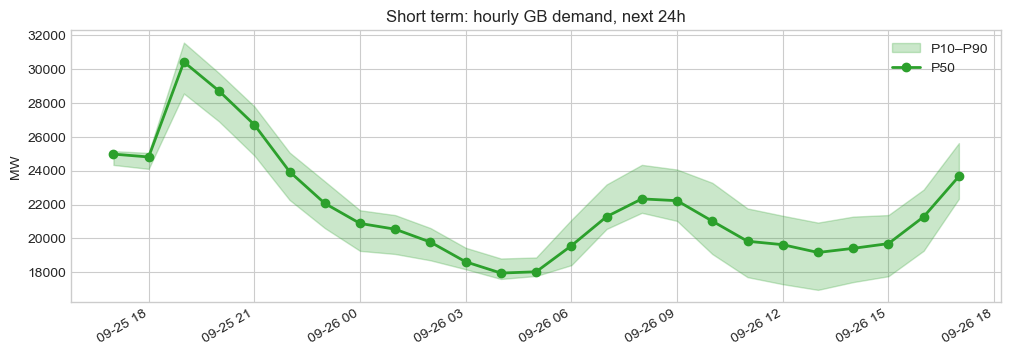

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(short["timestamp"], short["p10"], short["p90"], color="tab:green", alpha=0.25, label="P10–P90")
ax.plot(short["timestamp"], short["p50"], color="tab:green", linewidth=2, marker="o", label="P50")
actual = short.dropna(subset=["actual_mw"])
if not actual.empty:
    ax.plot(actual["timestamp"], actual["actual_mw"], color="black", linewidth=1.5, marker="o", label="INDO")
ax.set_title("Short term: hourly GB demand, next 24h")
ax.set_ylabel("MW")
ax.legend()
fig.autofmt_xdate()
plt.show()

## Medium term — next 7 days

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(medium["timestamp"], medium["p10"], medium["p90"], color="tab:orange", alpha=0.25, label="P10–P90")
ax.plot(medium["timestamp"], medium["p50"], color="tab:orange", linewidth=2, label="P50")
actual = medium.dropna(subset=["actual_mw"])
if not actual.empty:
    ax.plot(actual["timestamp"], actual["actual_mw"], color="black", linewidth=1.5, label="INDO")
ax.set_title("Medium term: hourly GB demand, next 7 days")
ax.set_ylabel("MW")
ax.legend()
fig.autofmt_xdate()
plt.show()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(medium["timestamp"], medium["interval_width"], color="tab:orange", linewidth=2, label="Medium hourly width")
ax.plot(short["timestamp"], short["interval_width"], color="tab:green", linewidth=2, marker="o", label="Short hourly width")
ax.set_title("Interval width by mode")
ax.set_ylabel("MW")
ax.legend()
fig.autofmt_xdate()
plt.show()

In [ ]:
out = ROOT / "data" / "processed"
short.to_csv(out / "latest_forecast_short.csv", index=False)
medium.to_csv(out / "latest_forecast_medium.csv", index=False)
medium.to_csv(out / "latest_forecast.csv", index=False)
print(f"Wrote {len(short)} short rows and {len(medium)} medium rows")